In [11]:
import random
import matplotlib.pyplot as plt

In [8]:
MASS = 0.5 # Mass of the beam in kg - 500g
BEAM_LENGTH = 0.3 # Length of the beam in meters - 30cm
BEAM_ARM_LENGTH =  BEAM_LENGTH / 2

BEAM_INERTIA = (1/12) * MASS * (BEAM_LENGTH ** 2)


In [46]:
DT = 0.01 # Time step in seconds
TIME = 30 # Total simulation time in seconds
TOTAL_STEPS = int(TIME / DT) # Total number of simulation steps

In [ ]:
target_angle = 0.0
current_angle = -25.0 
integral_error = 0.0
previous_error = 0.0

BASE_MOTOR_THRUST = 5.0  # Base thrust for each motor in Newtons

KP = 0.0
KI = 0.0
KD = 0.0

time_history = []
current_angle_history = []
target_angle_history = []

for step in range(TOTAL_STEPS):
    current_time = step * DT
        
    current_angle = current_angle + random.gauss(0, 0.001)  # Simulate some noise in the current angle measurement
    error = target_angle - current_angle

    integral_error += error * DT
    integral_error = max(min(integral_error, 10), -10)  # Anti-windup: limit the integral term

    derivative_error = (error - previous_error) / DT

    previous_error = error

    pid_output = (KP * error) + (KI * integral_error) + (KD * derivative_error)

    left_motor_thrust = BASE_MOTOR_THRUST - pid_output # CW
    right_motor_thrust = BASE_MOTOR_THRUST + pid_output # CCW

    left_motor_thrust = max(0, min(left_motor_thrust, 10))  # Ensure thrust is non-negative
    right_motor_thrust = max(0, min(right_motor_thrust, 10))  # Ensure thrust is non-negative


    net_torque = (right_motor_thrust - left_motor_thrust) * BEAM_ARM_LENGTH
    angular_acceleration = net_torque / BEAM_INERTIA
    angular_velocity = angular_acceleration * DT
    current_angle += angular_velocity * DT

    time_history.append(current_time)
    current_angle_history.append(current_angle)
    target_angle_history.append(target_angle)

Step: 0, Current Angle: -24.9996, Target Angle: 0.0000
Step: 1, Current Angle: -25.0005, Target Angle: 0.0000
Step: 2, Current Angle: -25.0004, Target Angle: 0.0000
Step: 3, Current Angle: -24.9998, Target Angle: 0.0000
Step: 4, Current Angle: -24.9972, Target Angle: 0.0000
Step: 5, Current Angle: -24.9986, Target Angle: 0.0000
Step: 6, Current Angle: -24.9984, Target Angle: 0.0000
Step: 7, Current Angle: -24.9978, Target Angle: 0.0000
Step: 8, Current Angle: -24.9986, Target Angle: 0.0000
Step: 9, Current Angle: -24.9975, Target Angle: 0.0000
Step: 10, Current Angle: -24.9960, Target Angle: 0.0000
Step: 11, Current Angle: -24.9963, Target Angle: 0.0000
Step: 12, Current Angle: -24.9951, Target Angle: 0.0000
Step: 13, Current Angle: -24.9961, Target Angle: 0.0000
Step: 14, Current Angle: -24.9960, Target Angle: 0.0000
Step: 15, Current Angle: -24.9958, Target Angle: 0.0000
Step: 16, Current Angle: -24.9964, Target Angle: 0.0000
Step: 17, Current Angle: -24.9942, Target Angle: 0.0000
St

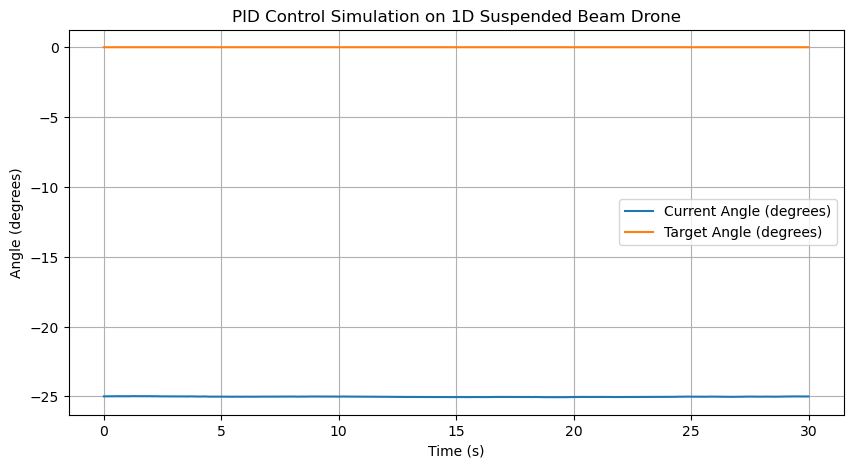

In [66]:
plt.figure(figsize=(10, 5))
plt.plot(time_history, current_angle_history, label='Current Angle (degrees)')
plt.plot(time_history, target_angle_history, label='Target Angle (degrees)')
plt.xlabel('Time (s)')
plt.ylabel('Angle (degrees)')
plt.title('PID Control Simulation on 1D Suspended Beam Drone')
plt.legend()
plt.grid(True)
plt.show()